In [1]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.shape

(50000, 2)

In [4]:
df.sample(10)

,review,sentiment
47737,One more of extremely unprofessional movies ab...,negative
14561,Not only was the plot of this film contrived w...,negative
20592,This truly is an Australia cult classic. If yo...,positive
41254,"Maybe this wowed them in the 50's, but this is...",negative
7202,"Not for everyone, but I really like it. Nice e...",positive
21414,"""Traffik 1989"" is an Emmy award winning six pa...",positive
38852,"Wow. I thought, Eskimo Limon was the most awfu...",negative
1368,This movie is supposed to be taking place in a...,negative
37245,"MacBeth, I've always thought, is the most acce...",negative
38519,What the heck is this about? Kelly (jennifer) ...,negative


In [5]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [6]:
df.isnull().sum()

,0
review,0
sentiment,0


In [7]:
from bs4 import BeautifulSoup
import re

def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = text.lower()
    text = re.sub(r"[^a-z0-9'/\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["review"] = df["review"].apply(clean_text)

In [8]:

# This cell creates a Python file containing the clean_text function.
# This file is then imported by subsequent cells for preprocessing new text.
with open('text_preprocessing_utils.py', 'w') as f:
    f.write('''from bs4 import BeautifulSoup
import re

def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = text.lower()
    text = re.sub(r"[^a-z0-9'/\s]", ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text
''')
print("text_preprocessing_utils.py created successfully.")


text_preprocessing_utils.py created successfully.


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2569/1025112558.py:10: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub(r"[^a-z0-9'/\s]", ' ', text)


In [9]:
print(df["review"].iloc[3])

basically there's a family where a little boy jake thinks there's a zombie in his closet his parents are fighting all the time this movie is slower than a soap opera and suddenly jake decides to become rambo and kill the zombie ok first of all when you're going to make a film you must decide if its a thriller or a drama as a drama the movie is watchable parents are divorcing arguing like in real life and then we have jake with his closet which totally ruins all the film i expected to see a boogeyman similar movie and instead i watched a drama with some meaningless thriller spots 3 out of 10 just for the well playing parents descent dialogs as for the shots with jake just ignore them


In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["sentiment"] = encoder.fit_transform(df["sentiment"])

In [11]:
X = df["review"]
y = df["sentiment"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
# TF-IDF + Logistic Regression baseline
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)
baseline_preds = baseline_model.predict(X_test_tfidf)

In [16]:
print("Baseline (TF-IDF + Logistic Regression)")
print("Accuracy:", accuracy_score(y_test, baseline_preds))
print("Precision:", precision_score(y_test, baseline_preds))
print("Recall:", recall_score(y_test, baseline_preds))
print("F1:", f1_score(y_test, baseline_preds))

Baseline (TF-IDF + Logistic Regression)
Accuracy: 0.8992
Precision: 0.8950910530482977
Recall: 0.9044
F1: 0.8997214484679665


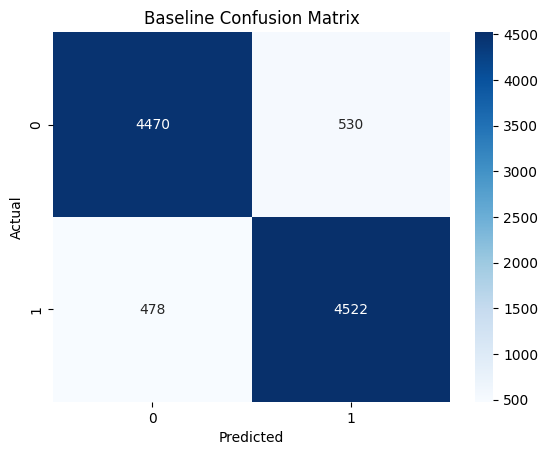

In [17]:
cm = confusion_matrix(y_test, baseline_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

In [19]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'a': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'in': 7,
 'it': 8,
 'i': 9,
 'this': 10,
 'that': 11,
 'was': 12,
 'as': 13,
 'for': 14,
 'with': 15,
 'movie': 16,
 'but': 17,
 'film': 18,
 'on': 19,
 'not': 20,
 'you': 21,
 'are': 22,
 'his': 23,
 'have': 24,
 'be': 25,
 'one': 26,
 'he': 27,
 'all': 28,
 'at': 29,
 'by': 30,
 'an': 31,
 'they': 32,
 'so': 33,
 'who': 34,
 'from': 35,
 'like': 36,
 'or': 37,
 'just': 38,
 'her': 39,
 'out': 40,
 'if': 41,
 'about': 42,
 "it's": 43,
 'has': 44,
 'there': 45,
 'some': 46,
 'what': 47,
 'good': 48,
 'when': 49,
 'more': 50,
 'very': 51,
 'up': 52,
 'no': 53,
 'time': 54,
 'even': 55,
 'my': 56,
 'would': 57,
 'she': 58,
 'which': 59,
 'really': 60,
 'only': 61,
 'see': 62,
 'story': 63,
 'their': 64,
 'had': 65,
 'can': 66,
 'me': 67,
 'were': 68,
 'well': 69,
 'we': 70,
 'much': 71,
 'than': 72,
 'bad': 73,
 'been': 74,
 'get': 75,
 'do': 76,
 'will': 77,
 'also': 78,
 'other': 79,
 'great': 80,
 'into': 81,
 'people': 82,

In [20]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [21]:
review_lengths = X_train.apply(lambda x: len(x.split()))

print(review_lengths.describe())

count    40000.000000
mean       230.957250
std        170.524586
min          6.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2466.000000
Name: review, dtype: float64


In [22]:
print(review_lengths.quantile(0.90))
print(review_lengths.quantile(0.95))
print(review_lengths.quantile(0.99))

451.0
588.0
900.010000000002


In [23]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 600

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [24]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 600)
(10000, 600)


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [27]:

vocab_size = 10000
embedding_dim = 128

model = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 92s 82ms/step - accuracy: 0.7595 - loss: 0.4980 - val_accuracy: 0.8428 - val_loss: 0.3585
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 86s 86ms/step - accuracy: 0.8013 - loss: 0.4403 - val_accuracy: 0.8635 - val_loss: 0.3305
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 85s 85ms/step - accuracy: 0.8978 - loss: 0.2679 - val_accuracy: 0.8981 - val_loss: 0.2562
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 99s 99ms/step - accuracy: 0.9273 - loss: 0.2035 - val_accuracy: 0.8906 - val_loss: 0.2725
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 90s 90ms/step - accuracy: 0.9486 - loss: 0.1541 - val_accuracy: 0.9022 - val_loss: 0.2624
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 88s 88ms/step - accuracy: 0.9621 - loss: 0.1188 - val_accuracy: 0.8949 - val_loss: 0.3070


In [29]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8888 - loss: 0.2683
Test Loss: 0.2683
Test Accuracy: 0.8888


In [36]:
bilstm_preds_raw = model.predict(X_test_pad)
bilstm_preds = (bilstm_preds_raw > 0.5).astype(int)

print("BiLSTM")
print("Accuracy:", accuracy_score(y_test, bilstm_preds))
print("Precision:", precision_score(y_test, bilstm_preds))
print("Recall:", recall_score(y_test, bilstm_preds))
print("F1:", f1_score(y_test, bilstm_preds))

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step
BiLSTM
Accuracy: 0.8888
Precision: 0.8944805194805194
Recall: 0.8816
F1: 0.8879935535858179


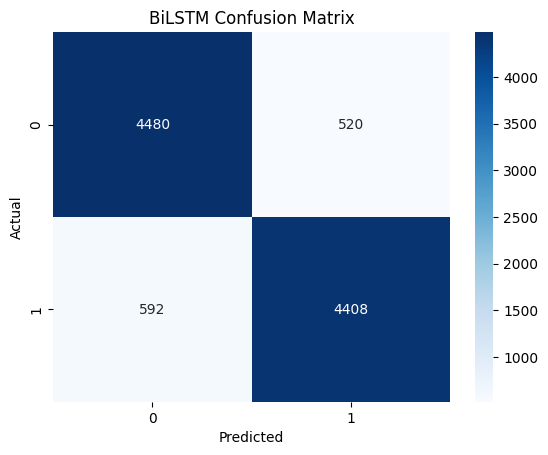

In [37]:
cm_bilstm = confusion_matrix(y_test, bilstm_preds)
sns.heatmap(cm_bilstm, annot=True, fmt="d", cmap="Blues")
plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

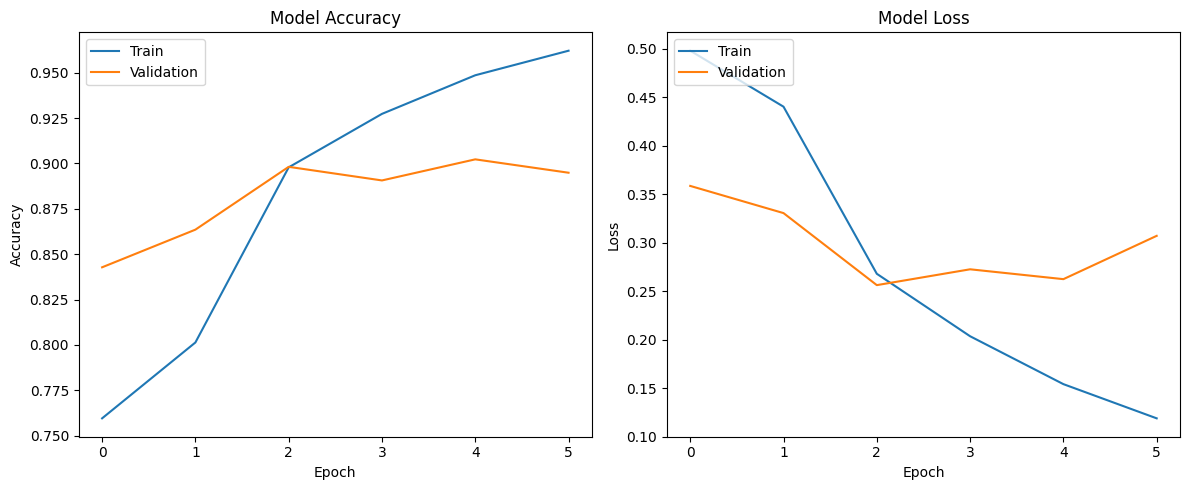

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [39]:
model.save('sentiment_model.keras')

In [40]:
import pickle

# Save the tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved as 'tokenizer.pkl'")

# Save the LabelEncoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print("LabelEncoder saved as 'label_encoder.pkl'")

Tokenizer saved as 'tokenizer.pkl'
LabelEncoder saved as 'label_encoder.pkl'


### Load Model and Preprocessing Objects

In [41]:
import tensorflow as tf
import pickle

# Load the Keras model
loaded_model = tf.keras.models.load_model('sentiment_model.keras')
print("Model loaded successfully.")

# Load the tokenizer
with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)
print("Tokenizer loaded successfully.")

# Load the LabelEncoder
with open('label_encoder.pkl', 'rb') as f:
    loaded_encoder = pickle.load(f)
print("LabelEncoder loaded successfully.")

Model loaded successfully.
Tokenizer loaded successfully.
LabelEncoder loaded successfully.
